In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import PIL


from tensorflow.core.protobuf import config_pb2
from tensorflow import keras
from tensorflow.keras import layers # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from keras.models import load_model
import pathlib

In [4]:
#Pega o diretório com as imagens usando Pathlib
data_dir = pathlib.Path("C:/Users/samuc/Downloads/flower_images") #Urls "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"  https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset/data
 
#Define o tamanho dos batchs e o tamnaho padrão das imagens / Define qual parte das imagens será de Treinamento e qual será de Validação 
batch_size = 8
img_height = 128
img_width = 128
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="training", seed=123, image_size=(img_height, img_width), batch_size=batch_size)
val_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="validation", seed=123, image_size=(img_height, img_width), batch_size=batch_size)
class_names = train_ds.class_names
num_classes = len(class_names)

#Insere os dados na memória cache e sobrepõe o pré-processamento dos dados e a execução do modelo durante a fase de treinamento 
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#Faz o aumento do Dataset modificando as imagens existentes 
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

#Cria as camadas da Rede Neural Convolucional junto das camadas Fully-Conected(Dense) usando o Sequential do Keras
model = Sequential([
  #input Block
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), #Transforma os valores dos pixels da imagem de 1/255 para 0/1
  #Conv Block 1
  layers.Conv2D(64, 3, padding='same'), #Faz a convolução das imagens com 16 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  #Conv Block 2
  layers.Conv2D(128, 3, padding='same'), #Faz a convolução das imagens com 32 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  #Res 1
  layers.Conv2D(128, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  layers.Conv2D(128, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  #Conv Block 3
  layers.Conv2D(256, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  #Conv Block 4
  layers.Conv2D(512, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  #Res 1
  layers.Conv2D(512, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  layers.Conv2D(512, 3, padding='same'), #Faz a convolução das imagens com 64 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.ReLU(),
  #Output Block
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  layers.Flatten(), #Vetoriza as matrizes dos tensores
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios 
  layers.Dense(512, activation='relu'), #Primeira camada Fully-Connected 
  layers.Dense(num_classes, activation='softmax')#Camada de saída da Rede, Onde cada  neurônio é uma classe 
])
#Define qual será a função de perda e qual será o modelo de optimização do Back-propagation
model.compile(optimizer='adam', #Utiliza do algoritmo otimizador Adaptative Moment estimation para as camadas convolucionais 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  #Utiliza da função de perda Cross Entropy para a parte Fully-Connected da rede
              metrics=['accuracy'])
model.build((None, 128, 128, 3)) #Executa as camadas 
model.summary(expand_nested=True) #Printa como estão alocadas as camadas da rede 


Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 128, 128, 3)       0         
|¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯|
| random_flip_1 (RandomFlip)  (None, 128, 128, 3)     0         |
|                                                               |
| random_rotation_1 (RandomRo  (None, 128, 128, 3)    0         |
| tation)                                                       |
|                                                               |
| random_zoom_1 (RandomZoom)  (None, 128, 128, 3)     0         |
¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯
 rescaling_1 (Rescaling)     (None, 128, 128, 3)       0         
                                         

In [5]:
#Faz o treinamento da rede utilizando do modelo criado 
epochs=10
history = model.fit(
  train_ds, #Dataset de treinamento
  validation_data=val_ds, #Dataset de validação
  epochs=epochs #Número de épocas 
)

Epoch 1/10


ResourceExhaustedError: in user code:

    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\engine\training.py", line 997, in train_step
        self.optimizer.minimize(loss, self.trainable_variables, tape=tape)
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\optimizers\optimizer_v2\optimizer_v2.py", line 579, in minimize
        return self.apply

In [11]:
print(history.history['val_accuracy'])

[0.7146000266075134, 0.75, 0.7635999917984009, 0.7932000160217285, 0.8029999732971191, 0.8137999773025513, 0.8149999976158142, 0.8184000253677368, 0.8252000212669373, 0.8381999731063843, 0.8450000286102295, 0.8321999907493591, 0.8450000286102295, 0.8325999975204468, 0.8510000109672546, 0.8438000082969666, 0.8428000211715698, 0.8525999784469604, 0.8582000136375427, 0.8525999784469604, 0.8521999716758728, 0.8569999933242798, 0.8644000291824341, 0.8450000286102295, 0.8592000007629395]


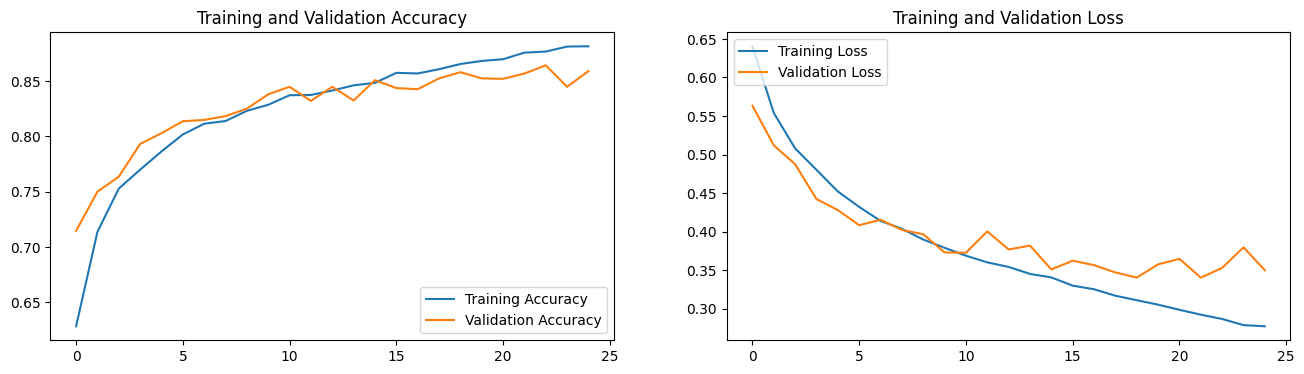

In [13]:
#Faz um gráfico utilizando da Acurácia e da Perda entre os dados de Treinamento e os Dados de Validação
plt.figure(figsize=(16, 4)) #Tamanho da imagem

plt.subplot(1, 2, 1) #Tamanho da Sub-Imagem da Esquerda
plt.plot(range(epochs), history.history['accuracy'], label='Training Accuracy') #Dados de Acurácia dos dados de treino para sub-imagem da esquerda
plt.plot(range(epochs),  history.history['val_accuracy'], label='Validation Accuracy') #Dados de Acurácia dos dados de validação para sub-imagem da esquerda
plt.legend(loc='lower right') #Local da legenda da sub-imagem da esquerda
plt.title('Training and Validation Accuracy') #Título da sub-imagem da esquerda

plt.subplot(1, 2, 2) #Tamanho da Sub-Imagem da Direita
plt.plot(range(epochs), history.history['loss'], label='Training Loss') #Dados da Perda dos dados de treino para sub-imagem da direita
plt.plot(range(epochs), history.history['val_loss'], label='Validation Loss') #Dados da Perda dos dados de validação para sub-imagem direita
plt.legend(loc='upper left') #Local da legenda da sub-imagem da direita
plt.title('Training and Validation Loss') #Título da sub-imagem da direita 
plt.show()

In [ ]:
roses = list(data_dir.glob('roses/*')) #Carrega todas as imagens das rosas do Dataset em uma lista
dandelion = list(data_dir.glob('dandelion/*')) #Carrega todas as imagens dos dentes de leão do Dataset em uma lista
tulips = list(data_dir.glob('tulips/*')) #Carrega todas as imagens das tulipas do Dataset em uma lista
sunflowers = list(data_dir.glob('sunflowers/*')) #Carrega todas as imagens dos girassoís do Dataset em uma lista
daisy = list(data_dir.glob('daisy/*')) #Carrega todas as imagens das margaridas do Dataset em uma lista
im = PIL.Image.open(dandelion[130])

In [5]:
orchids = list(data_dir.glob('Orchid/*')) #Carrega todas as imagens das rosas do Dataset em uma lista
lotus = list(data_dir.glob('Lotus/*')) #Carrega todas as imagens dos dentes de leão do Dataset em uma lista
tulips = list(data_dir.glob('Tulip/*')) #Carrega todas as imagens das tulipas do Dataset em uma lista
sunflowers = list(data_dir.glob('Sunflower/*')) #Carrega todas as imagens dos girassoís do Dataset em uma lista
lillys = list(data_dir.glob('Lilly/*')) #Carrega todas as imagens das margaridas do Dataset em uma lista
im = PIL.Image.open(lillys[110])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Essa imagem pertence a classe Lilly com 99.26 porcento de predicão.


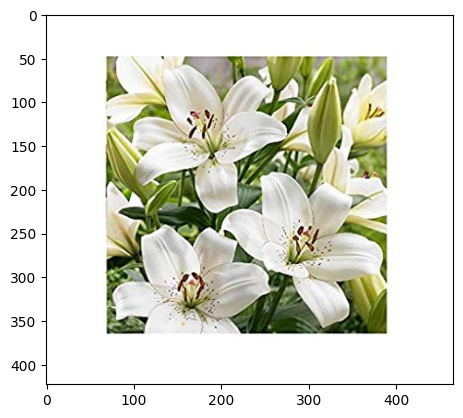

In [6]:

#im = PIL.Image.open('C:/Users/davic/Downloads/Tulips.JPEG') #Carrega uma das imagens em uma variável
plt.imshow(im) #Printa a imagem
im = im.resize((180,180)) #Rescala a Imagem no formato 180x180
im_array = np.array(im) #Vetoriza a imagem no formato 180x180
im_array = np.expand_dims(im_array, axis = 0) #Rescalona a imagem no formato 180x180x1 para ficar no estilo do Keras/TEnsorFlow
score = model.predict(im_array) #Faz a predição da imagem

print("Essa imagem pertence a classe {} com {:.2f} porcento de predicão.".format(class_names[np.argmax(score)], 100 * np.max(score))) #Printa o score da imagem dizendo a qual classe ela pertence 